# CO2 Emissions Forecasting with Prophet
This notebook trains a Prophet model to forecast CO2 emissions for the next 10 years. It also includes an evaluation step using a train/test split.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

### 1. Load and Preprocess Data
Prophet requires the time series dataframe to have two specific columns: `ds` (for dates) and `y` (for the values to predict).

In [5]:
# Load dataset
df = pd.read_csv("data.csv")

# Filter for Total Energy Electric Power Sector
df = df[df["Description"] == "Total Energy Electric Power Sector CO2 Emissions"].copy()

# Convert YYYYMM to datetime
df["ds"] = pd.to_datetime(df["YYYYMM"], format="%Y%m", errors="coerce")

# Convert Value to numeric, forcing non-numeric to NaN
df["y"] = pd.to_numeric(df["Value"], errors="coerce")
df = df.dropna(subset=["y"])
df = df.dropna(subset=["ds"])

# Keep only the required columns and sort by date
prophet_df = df[["ds", "y"]].sort_values("ds").reset_index(drop=True)
prophet_df.head()

,ds,y
0,1973-01-01,111.621
1,1973-02-01,99.185
2,1973-03-01,99.112
3,1973-04-01,93.183
4,1973-05-01,98.012


### 2. Model Evaluation (Train/Test Split)
To calculate metrics like MAPE and RMSE, we will hold out the last 2 years of data for testing.

In [6]:
# Split data into train and test sets (last 24 months for testing)
test_months = 24
train = prophet_df.iloc[:-test_months]
test = prophet_df.iloc[-test_months:]

# Initialize and train Prophet on training data
eval_model = Prophet(seasonality_mode="multiplicative")
eval_model.fit(train)

# Predict on the test dates
future_eval = eval_model.make_future_dataframe(periods=test_months, freq="MS")
forecast_eval = eval_model.predict(future_eval)

# Extract predictions matching the test set
predictions = forecast_eval.iloc[-test_months:]["yhat"].values
actuals = test["y"].values

# Calculate metrics
mape = mean_absolute_percentage_error(actuals, predictions) * 100
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))

print(f"Evaluation Metrics on Last 2 Years:")
print(f"MAPE: {mape:.2f}%")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

10:32:57 - cmdstanpy - INFO - Chain [1] start processing
10:32:58 - cmdstanpy - INFO - Chain [1] done processing


Evaluation Metrics on Last 2 Years:
MAPE: 8.25%
MAE:  11.37
RMSE: 14.95


*(Note: F1 Score is a metric for classification problems, not regression forecasting, which is why we use MAPE, MAE, and RMSE here.)*

### 3. Final Model & 10-Year Forecast
Now we train a new model on the *entire* historical dataset to get the best possible 10-year forecast.

In [7]:
# Train on full dataset
final_model = Prophet(seasonality_mode="multiplicative")
final_model.fit(prophet_df)

# Create future dates for 10 years (120 months)
future_10yr = final_model.make_future_dataframe(periods=120, freq="MS")

# Make predictions
forecast_10yr = final_model.predict(future_10yr)

forecast_10yr[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

10:33:27 - cmdstanpy - INFO - Chain [1] start processing
10:33:28 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
638,2026-03-01,101.863735,88.569783,114.140650
639,2026-04-01,93.472721,80.664233,106.287242
640,2026-05-01,100.648331,87.434272,113.556585
641,2026-06-01,112.791560,98.338286,126.202030
642,2026-07-01,127.408561,112.392019,141.792220


### 4. Plot the Forecast

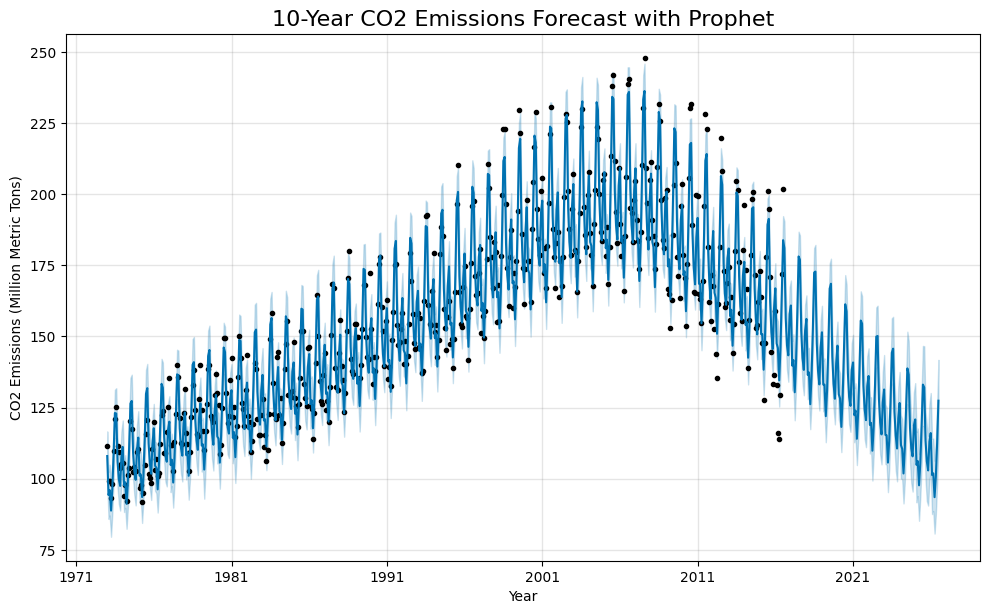

In [8]:
# Plot the forecast using Prophet built-in plotting
fig1 = final_model.plot(forecast_10yr)
plt.title("10-Year CO2 Emissions Forecast with Prophet", fontsize=16)
plt.xlabel("Year")
plt.ylabel("CO2 Emissions (Million Metric Tons)")
plt.show()

### 5. Plot Forecast Components
Prophet breaks down the forecast into the underlying trend and yearly seasonality.

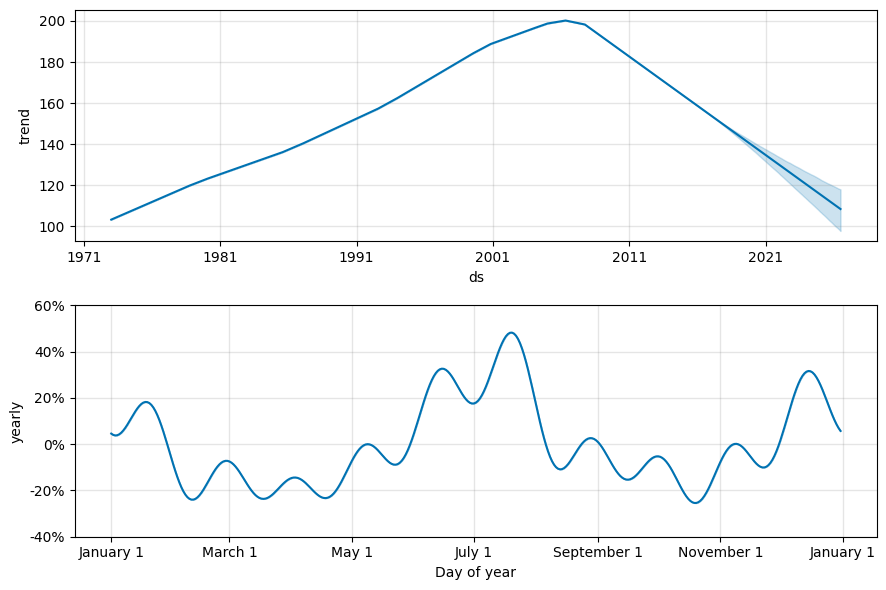

In [9]:
# Plot components
fig2 = final_model.plot_components(forecast_10yr)
plt.show()